# H&E histological patch classification

Members: Théo, Jehan, Matthieu

Import the librairies that will be used :
- os for the path management
- shutil for copypath
- jolib to save and loads the models
- sklearn for the machine learning algorithms
- numpy and pandas for math and data
- PIL for image loading

We pre prepared and added the paths for the different folders and CSV files we will use later on.

## Imports and paths

In [8]:
import warnings
warnings.simplefilter("ignore")

import os
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

CWD = os.getcwd()
ROOT_DIR = CWD

DATA_DIR = os.path.join(ROOT_DIR, "data")
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "datasetjehan")
TEST_IMG_DIR = os.path.join(DATA_DIR, "tdatasetJehan")
QUALITY_DIR = os.path.join(DATA_DIR, "quality_control")
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, "features_train.csv")
MODEL_PATH = os.path.join(DATA_DIR, "best_model.joblib")
FIG_DIR = os.path.join(DATA_DIR, "figures")

N_EXAMPLES_PER_CLASS = 5
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
print(CWD)

/workspaces/cell_classification/src


## Part I/ Data exploration

We start by loading the CSV file and summarize the dataset. We added a quality control folder and finally we display the label distribution to have a better idea of the repartition of the dataset. Hence, it will help us to see if there is imbalance between the classes, and we prepare the folders we will use later.


Total samples: 400
Labels: ['Fibroblast', 'Lymphocyte', 'Plasma', 'Tumor']
Label
Lymphocyte    100
Tumor         100
Plasma        100
Fibroblast    100
Name: count, dtype: int64


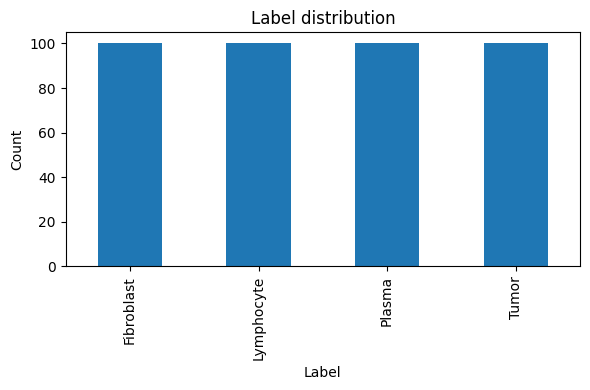

Imbalance ratio (max/min): 1.00


In [9]:
train_df = pd.read_csv(TRAIN_CSV)

num_samples = len(train_df)
label_names = sorted(train_df["Label"].unique())
label_counts = train_df["Label"].value_counts()

print(f"Total samples: {num_samples}")
print(f"Labels: {label_names}")
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.reindex(label_names).plot(kind="bar")
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "label_distribution.png"))
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

os.makedirs(QUALITY_DIR, exist_ok=True)
for label in label_names:
    os.makedirs(os.path.join(QUALITY_DIR, str(label)), exist_ok=True)


def find_image_path(img_id, img_dir):
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
    for ext in exts:
        candidate = os.path.join(img_dir, f"{img_id}{ext}")
        if os.path.exists(candidate):
            return candidate
    return None


for _, row in train_df.iterrows():
    img_id = row["Image"]
    label = row["Label"]
    src_path = find_image_path(img_id, TRAIN_IMG_DIR)
    if src_path is None:
        continue
    dst_path = os.path.join(QUALITY_DIR, str(label), os.path.basename(src_path))
    if not os.path.exists(dst_path):
        shutil.copyfile(src_path, dst_path)

We can see first that there is 4 different labels: Fibroblast, lymphocyte, Plasma and Tumor. Those 4 labels has the exact same amount each, meaning that each class are perfectly balanced, moreover there is 400 total samples, which make this dataset really good for machine learning. It leaves enough images for both the training set and the testing set.
We chose not to remove pictures as there will be potentially similar one in the final dataset. 


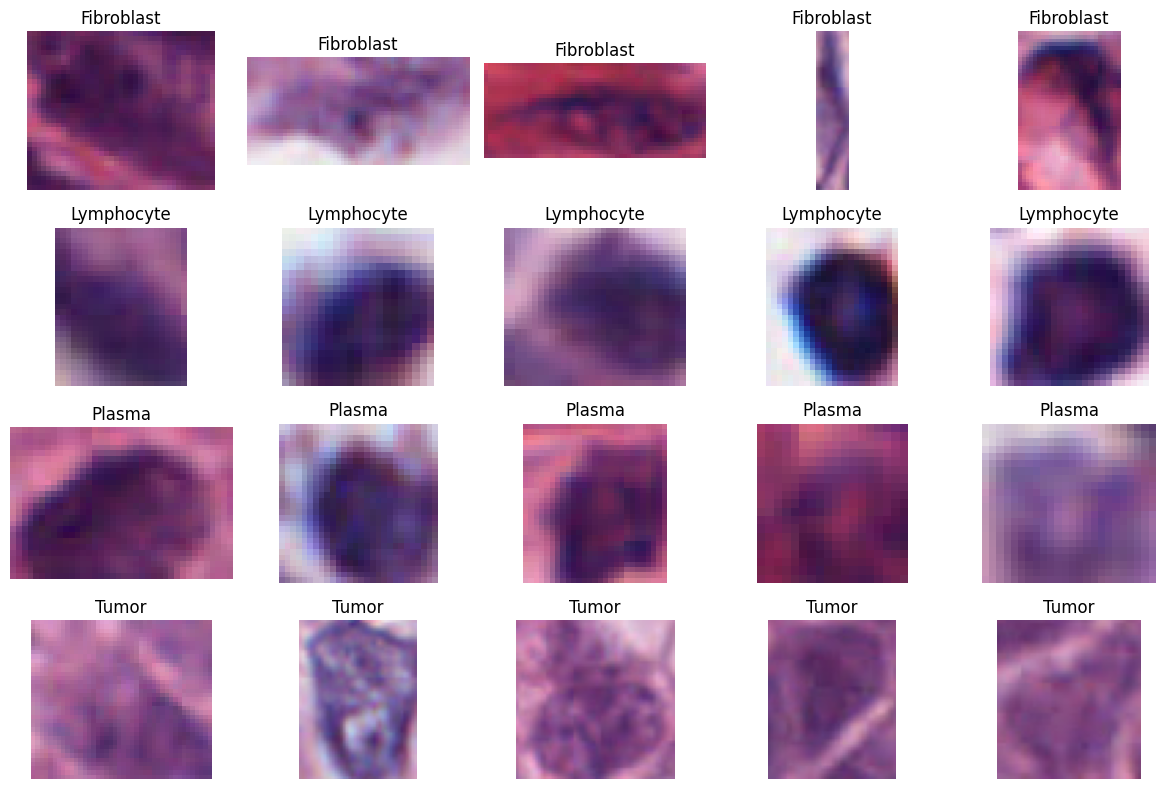

In [10]:
np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(
    len(label_names),
    N_EXAMPLES_PER_CLASS,
    figsize=(12, 2 * len(label_names)),
)

if len(label_names) == 1:
    axes = np.array([axes])

for i, label in enumerate(label_names):
    subset = train_df[train_df["Label"] == label]
    sample_rows = subset.sample(
        n=min(N_EXAMPLES_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE,
    )

    for j, (_, row) in enumerate(sample_rows.iterrows()):
        ax = axes[i, j]
        ax.axis("off")
        img_path = find_image_path(row["Image"], TRAIN_IMG_DIR)
        if img_path is None:
            ax.set_title("Missing")
            continue
        img = Image.open(img_path).convert("RGB")
        ax.imshow(np.asarray(img))
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "examples_grid.png"))
plt.show()

From a first glance, we can see few differences between the classes and already imagines which ones will be harder or easier to classify. For instance, the Lymphocyte is long and has a really distinctive shape compared to the other types which are really round such as the lymphocytes and the plasma. We cal also see that lymphocytes are especially dark, but some look simirlar to some pictures of plasma. However their colors do are a bit different, lyphocyte are more blue, where the plasma seems to have some tints of red and blue, and more variation in color within the plasma. The Tumor's seems bigger than the others with a different texture in it. I can also see that the tumor seems to have a different texture than the others. Finally, 

Through this first analyse, I predict that firbroblast and tumors will be the easiest to predict, wherease Plasma and lymphocyte whom can be similar will be harder.

## Part II/ feature extraction

From the last analysis, i saw multiple different features that seems relevent. 
- Area features: area ratio of the detected cell/tissue region.
- Shape features: eccentricity, compactness, or aspect ratio.
- Intensity features: mean grayscale intensity and dark pixel ratio.
- Color features: mean red intensity and mean blue intensity.
- Texture features: texture contrast descriptor (saw in computer vision class).
- Perimeter feature: perimeter of the detected cell/tissue region.

  

In [11]:
def load_rgb_image(path):
    img = Image.open(path).convert("RGB")
    return np.asarray(img, dtype=np.uint8)


def grayscale_image(rgb):
    rgb_float = rgb.astype(np.float64) / 255.0
    return (
        0.2126 * rgb_float[:, :, 0]
        + 0.7152 * rgb_float[:, :, 1]
        + 0.0722 * rgb_float[:, :, 2]
    )


def otsu_threshold_np(gray):
    values = np.clip(gray.ravel(), 0.0, 1.0)
    hist, bin_edges = np.histogram(values, bins=256, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    prob = hist / max(hist.sum(), 1.0)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    omega = np.cumsum(prob)
    mu = np.cumsum(prob * centers)
    mu_total = mu[-1]
    denom = omega * (1.0 - omega)
    valid = denom > 1e-12

    sigma_b = np.zeros_like(centers)
    sigma_b[valid] = (mu_total * omega[valid] - mu[valid]) ** 2 / denom[valid]
    return float(centers[np.argmax(sigma_b)])


def neighbors8(row, col, height, width):
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            nr, nc = row + dr, col + dc
            if 0 <= nr < height and 0 <= nc < width:
                yield nr, nc


def connected_components_np(mask):
    mask = mask.astype(bool)
    height, width = mask.shape
    labels = np.zeros(mask.shape, dtype=np.int32)
    sizes = []
    label = 0

    for row in range(height):
        for col in range(width):
            if not mask[row, col] or labels[row, col] != 0:
                continue
            label += 1
            stack = [(row, col)]
            labels[row, col] = label
            size = 0
            while stack:
                r, c = stack.pop()
                size += 1
                for nr, nc in neighbors8(r, c, height, width):
                    if mask[nr, nc] and labels[nr, nc] == 0:
                        labels[nr, nc] = label
                        stack.append((nr, nc))
            sizes.append(size)

    return labels, np.asarray(sizes, dtype=np.int64)


def remove_small_objects_np(mask, min_size=16):
    labels, sizes = connected_components_np(mask)
    cleaned = np.zeros_like(mask, dtype=bool)
    for label, size in enumerate(sizes, start=1):
        if size >= min_size:
            cleaned |= labels == label
    return cleaned


def fill_small_holes_np(mask, max_size=16):
    inv = ~mask.astype(bool)
    labels, sizes = connected_components_np(inv)
    height, width = mask.shape
    filled = mask.copy().astype(bool)

    border_labels = set(labels[0, :]) | set(labels[-1, :])
    border_labels |= set(labels[:, 0]) | set(labels[:, -1])
    border_labels.discard(0)

    for label, size in enumerate(sizes, start=1):
        if label not in border_labels and size <= max_size:
            filled[labels == label] = True
    return filled


def largest_component_np(mask):
    labels, sizes = connected_components_np(mask)
    if len(sizes) == 0:
        return mask.astype(bool)
    main_label = int(np.argmax(sizes) + 1)
    return labels == main_label


def perimeter_np(mask):
    mask = mask.astype(bool)
    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    center = padded[1:-1, 1:-1]
    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]
    border = center & (~up | ~down | ~left | ~right)
    return float(border.sum())


def tissue_mask(rgb):
    gray = grayscale_image(rgb)
    threshold = otsu_threshold_np(gray)
    mask = gray < threshold
    ratio = mask.mean()

    if ratio < 0.01 or ratio > 0.95:
        mask = gray < np.percentile(gray, 90)

    mask = remove_small_objects_np(mask, min_size=16)
    mask = fill_small_holes_np(mask, max_size=16)
    return mask

### Area, shape and perimeter features

This function return multiple features from the biggest label of the mask.
First, there is the area ratio which look at how much of the image does the cell take.
Secondly, there is the eccentricity which show how long is the shape, which is especially good to find the fitoblast from what we analysed earlier.
the bbox aspect ratio show how the witdh is compare to the height, so in other word, a ratio of 1 would mean that its a perfect square or circle, whereas a ratio close to 0 would mean that it is closer to a string. 
The compactness shows how close to a circle the shape is, a 1 would be a perfect circle, whereas a ratio closer to 0 would mean a really stringy or weird shape. From my former analysis, i think this would be a really good way to discriminate both fibroblast which are long and the tumors who are less stringy shaped, but are not almost perfect circles such as lymphocites and plasma.
Finally the perimeter ratio shows the ratio of the contour of a shape compared to the number of pixel in this shape. Therefore, the stranger and long the shape will be, the higher this ratio will be.

In [12]:
def area_shape_perimeter_features(mask):
    height, width = mask.shape
    total_pixels = height * width
    main = largest_component_np(mask)
    area_pixels = int(main.sum())
    eps = 1e-8

    labels, sizes = connected_components_np(mask)
    n_components = int(len(sizes))

    if area_pixels == 0:
        return {
            "area_ratio": float(mask.mean()),
            "main_area_ratio": 0.0,
            "background_ratio": 1.0,
            "n_components": 0.0,
            "perimeter_ratio": 0.0,
            "compactness": 0.0,
            "eccentricity": 0.0,
            "bbox_aspect_ratio": 0.0,
            "bbox_extent": 0.0,
            "centroid_x": 0.0,
            "centroid_y": 0.0,
            "std_radial": 0.0,
        }

    coords = np.column_stack(np.nonzero(main))
    rows = coords[:, 0]
    cols = coords[:, 1]
    row_min, row_max = rows.min(), rows.max()
    col_min, col_max = cols.min(), cols.max()
    bbox_height = row_max - row_min + 1
    bbox_width = col_max - col_min + 1

    centroid_y = float(rows.mean() / max(height - 1, 1))
    centroid_x = float(cols.mean() / max(width - 1, 1))

    if len(coords) >= 2:
        centered = coords.astype(np.float64) - coords.mean(axis=0)
        cov = np.cov(centered.T) + eps * np.eye(2)
        eigvals = np.maximum(np.linalg.eigvalsh(cov), eps)
        eccentricity = np.sqrt(1.0 - eigvals.min() / eigvals.max())
    else:
        eccentricity = 0.0

    perimeter = perimeter_np(main)
    compactness = 4.0 * np.pi * area_pixels / ((perimeter + eps) ** 2)

    radial = np.sqrt((rows - rows.mean()) ** 2 + (cols - cols.mean()) ** 2)
    bbox_area = bbox_height * bbox_width

    return {
        "area_ratio": float(mask.mean()),
        "main_area_ratio": float(area_pixels / total_pixels),
        "background_ratio": float(1.0 - mask.mean()),
        "n_components": float(n_components),
        "perimeter_ratio": float(perimeter / total_pixels),
        "compactness": float(compactness),
        "eccentricity": float(eccentricity),
        "bbox_aspect_ratio": float(bbox_width / max(bbox_height, 1)),
        "bbox_extent": float(area_pixels / max(bbox_area, 1)),
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "std_radial": float(np.std(radial)),
    }


def masked_values(array, mask):
    values = array[mask]
    if values.size == 0:
        values = array.ravel()
    return values.astype(np.float64)


def rgb_to_hsv_np(rgb):
    rgb = rgb.astype(np.float64) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    maxc = np.max(rgb, axis=2)
    minc = np.min(rgb, axis=2)
    delta = maxc - minc

    hue = np.zeros_like(maxc)
    nonzero = delta > 1e-12

    idx = (maxc == r) & nonzero
    hue[idx] = ((g[idx] - b[idx]) / delta[idx]) % 6
    idx = (maxc == g) & nonzero
    hue[idx] = ((b[idx] - r[idx]) / delta[idx]) + 2
    idx = (maxc == b) & nonzero
    hue[idx] = ((r[idx] - g[idx]) / delta[idx]) + 4
    hue = hue / 6.0

    saturation = np.zeros_like(maxc)
    saturation[maxc > 1e-12] = delta[maxc > 1e-12] / maxc[maxc > 1e-12]
    value = maxc
    return hue, saturation, value


def intensity_color_features(rgb, mask):
    gray = grayscale_image(rgb)
    gray_values = masked_values(gray, mask)
    rgb_float = rgb.astype(np.float64) / 255.0
    red = masked_values(rgb_float[:, :, 0], mask)
    green = masked_values(rgb_float[:, :, 1], mask)
    blue = masked_values(rgb_float[:, :, 2], mask)
    hue, saturation, value = rgb_to_hsv_np(rgb)
    hue_values = masked_values(hue, mask)
    saturation_values = masked_values(saturation, mask)

    return {
        "gray_mean": float(np.mean(gray_values)),
        "gray_std": float(np.std(gray_values)),
        "gray_min": float(np.min(gray_values)),
        "gray_max": float(np.max(gray_values)),
        "dark_pixel_ratio": float(np.mean(gray_values < np.percentile(gray, 25))),
        "red_mean": float(np.mean(red)),
        "green_mean": float(np.mean(green)),
        "blue_mean": float(np.mean(blue)),
        "red_std": float(np.std(red)),
        "green_std": float(np.std(green)),
        "blue_std": float(np.std(blue)),
        "blue_red_ratio": float(np.mean(blue) / (np.mean(red) + 1e-8)),
        "hue_mean": float(np.mean(hue_values)),
        "saturation_mean": float(np.mean(saturation_values)),
        "value_mean": float(np.mean(masked_values(value, mask))),
    }


def glcm_np(gray, levels=16, dx=1, dy=0):
    gray_q = np.clip((gray * levels).astype(np.int32), 0, levels - 1)
    mat = np.zeros((levels, levels), dtype=np.float64)
    height, width = gray_q.shape

    y0 = max(0, -dy)
    y1 = min(height, height - dy)
    x0 = max(0, -dx)
    x1 = min(width, width - dx)

    a = gray_q[y0:y1, x0:x1].ravel()
    b = gray_q[y0 + dy:y1 + dy, x0 + dx:x1 + dx].ravel()

    for i, j in zip(a, b):
        mat[i, j] += 1.0
        mat[j, i] += 1.0

    total = mat.sum()
    if total > 0:
        mat /= total
    return mat


def texture_features(rgb, mask):
    gray = grayscale_image(rgb)
    gray_values = masked_values(gray, mask)
    matrices = [
        glcm_np(gray, levels=16, dx=1, dy=0),
        glcm_np(gray, levels=16, dx=0, dy=1),
        glcm_np(gray, levels=16, dx=1, dy=1),
        glcm_np(gray, levels=16, dx=1, dy=-1),
    ]

    contrasts = []
    homogeneities = []
    energies = []
    i_idx, j_idx = np.indices((16, 16))

    for mat in matrices:
        contrasts.append(np.sum(((i_idx - j_idx) ** 2) * mat))
        homogeneities.append(np.sum(mat / (1.0 + np.abs(i_idx - j_idx))))
        energies.append(np.sum(mat ** 2))

    return {
        "texture_contrast": float(np.mean(contrasts)),
        "texture_homogeneity": float(np.mean(homogeneities)),
        "texture_energy": float(np.mean(energies)),
        "texture_gray_range": float(np.ptp(gray_values)),
    }


def extract_features_from_path(img_path):
    rgb = load_rgb_image(img_path)
    mask = tissue_mask(rgb)

    features_dict = {}
    features_dict.update(area_shape_perimeter_features(mask))
    features_dict.update(intensity_color_features(rgb, mask))
    features_dict.update(texture_features(rgb, mask))
    return features_dict


def build_feature_table(df, image_dir, include_labels=True):
    rows = []
    n_total = len(df)

    for count, (_, row) in enumerate(df.iterrows(), start=1):
        img_id = row["Image"]
        img_path = find_image_path(img_id, image_dir)

        if img_path is None:
            print(f"Missing image: {img_id}")
            continue

        try:
            features_row = extract_features_from_path(img_path)
        except Exception as exc:
            print(f"Error with {img_id}: {exc}")
            continue

        features_row["Image"] = img_id
        if include_labels:
            features_row["Label"] = row["Label"]
        rows.append(features_row)

        if count % 50 == 0 or count == n_total:
            print(f"Processed {count}/{n_total} images")

    return pd.DataFrame(rows)

In [13]:
features_df = build_feature_table(
    train_df,
    TRAIN_IMG_DIR,
    include_labels=True,
)

features_df.to_csv(FEATURES_TRAIN_CSV, index=False)
print(f"Saved features to: {FEATURES_TRAIN_CSV}")
features_df.head()

Missing image: 0
Missing image: 1
Missing image: 2
Missing image: 3
Missing image: 4
Missing image: 5
Missing image: 6
Missing image: 7
Missing image: 8
Missing image: 9
Processed 50/400 images
Processed 100/400 images
Processed 150/400 images
Processed 200/400 images
Processed 250/400 images
Processed 300/400 images
Processed 350/400 images
Processed 400/400 images
Saved features to: /workspaces/cell_classification/src/data/features_train.csv


,area_ratio,main_area_ratio,background_ratio,n_components,perimeter_ratio,compactness,eccentricity,bbox_aspect_ratio,bbox_extent,centroid_x,...,blue_red_ratio,hue_mean,saturation_mean,value_mean,texture_contrast,texture_homogeneity,texture_energy,texture_gray_range,Image,Label
0,0.588571,0.588571,0.411429,1.0,0.080000,0.943394,0.660581,1.032258,0.726815,0.546912,...,1.149487,0.768185,0.326631,0.631672,0.592863,0.769164,0.052372,0.291914,10,Fibroblast
1,0.556277,0.556277,0.443723,1.0,0.085498,1.034949,0.805392,1.333333,0.669271,0.569188,...,1.151247,0.801140,0.686248,0.256680,0.510000,0.820333,0.135374,0.151264,11,Lymphocyte
2,0.665385,0.665385,0.334615,1.0,0.101282,1.045016,0.626299,0.785714,0.842532,0.622428,...,1.566672,0.732932,0.589192,0.361691,1.333912,0.714980,0.086513,0.363625,12,Lymphocyte
3,0.557406,0.547293,0.442594,2.0,0.124926,0.262156,0.593290,1.000000,0.547293,0.594810,...,1.128115,0.787700,0.399798,0.575399,0.370926,0.824913,0.104826,0.226631,13,Tumor
4,0.636905,0.636905,0.363095,1.0,0.119709,0.369385,0.870266,2.160000,0.713333,0.449578,...,1.035765,0.809620,0.224384,0.732710,0.445126,0.794590,0.081689,0.339806,14,Fibroblast


### Feature visualization

,feature,Fibroblast_mean,Fibroblast_std,Lymphocyte_mean,Lymphocyte_std,Plasma_mean,Plasma_std,Tumor_mean,Tumor_std
0,area_ratio,0.572683,0.120072,0.659864,0.090450,0.685021,0.093420,0.625435,0.104428
1,main_area_ratio,0.554986,0.122004,0.657480,0.093269,0.682421,0.096269,0.600668,0.135723
2,background_ratio,0.427317,0.120072,0.340136,0.090450,0.314979,0.093420,0.374565,0.104428
3,n_components,1.535354,0.848926,1.041667,0.200875,1.051546,0.222258,1.602041,0.971127
4,perimeter_ratio,0.095452,0.029276,0.117015,0.030285,0.116211,0.025621,0.111917,0.034968
5,compactness,0.505491,0.204782,0.970698,0.136145,0.904536,0.188282,0.427387,0.273765
6,eccentricity,0.881366,0.097452,0.656127,0.139424,0.629408,0.139392,0.692927,0.159406
7,bbox_aspect_ratio,1.356588,0.788010,1.051175,0.268167,1.042105,0.258979,1.149388,0.396269
8,bbox_extent,0.613925,0.118091,0.776180,0.063764,0.782809,0.084420,0.652047,0.115999
9,centroid_x,0.526815,0.072424,0.556224,0.054322,0.553428,0.050225,0.514355,0.075367


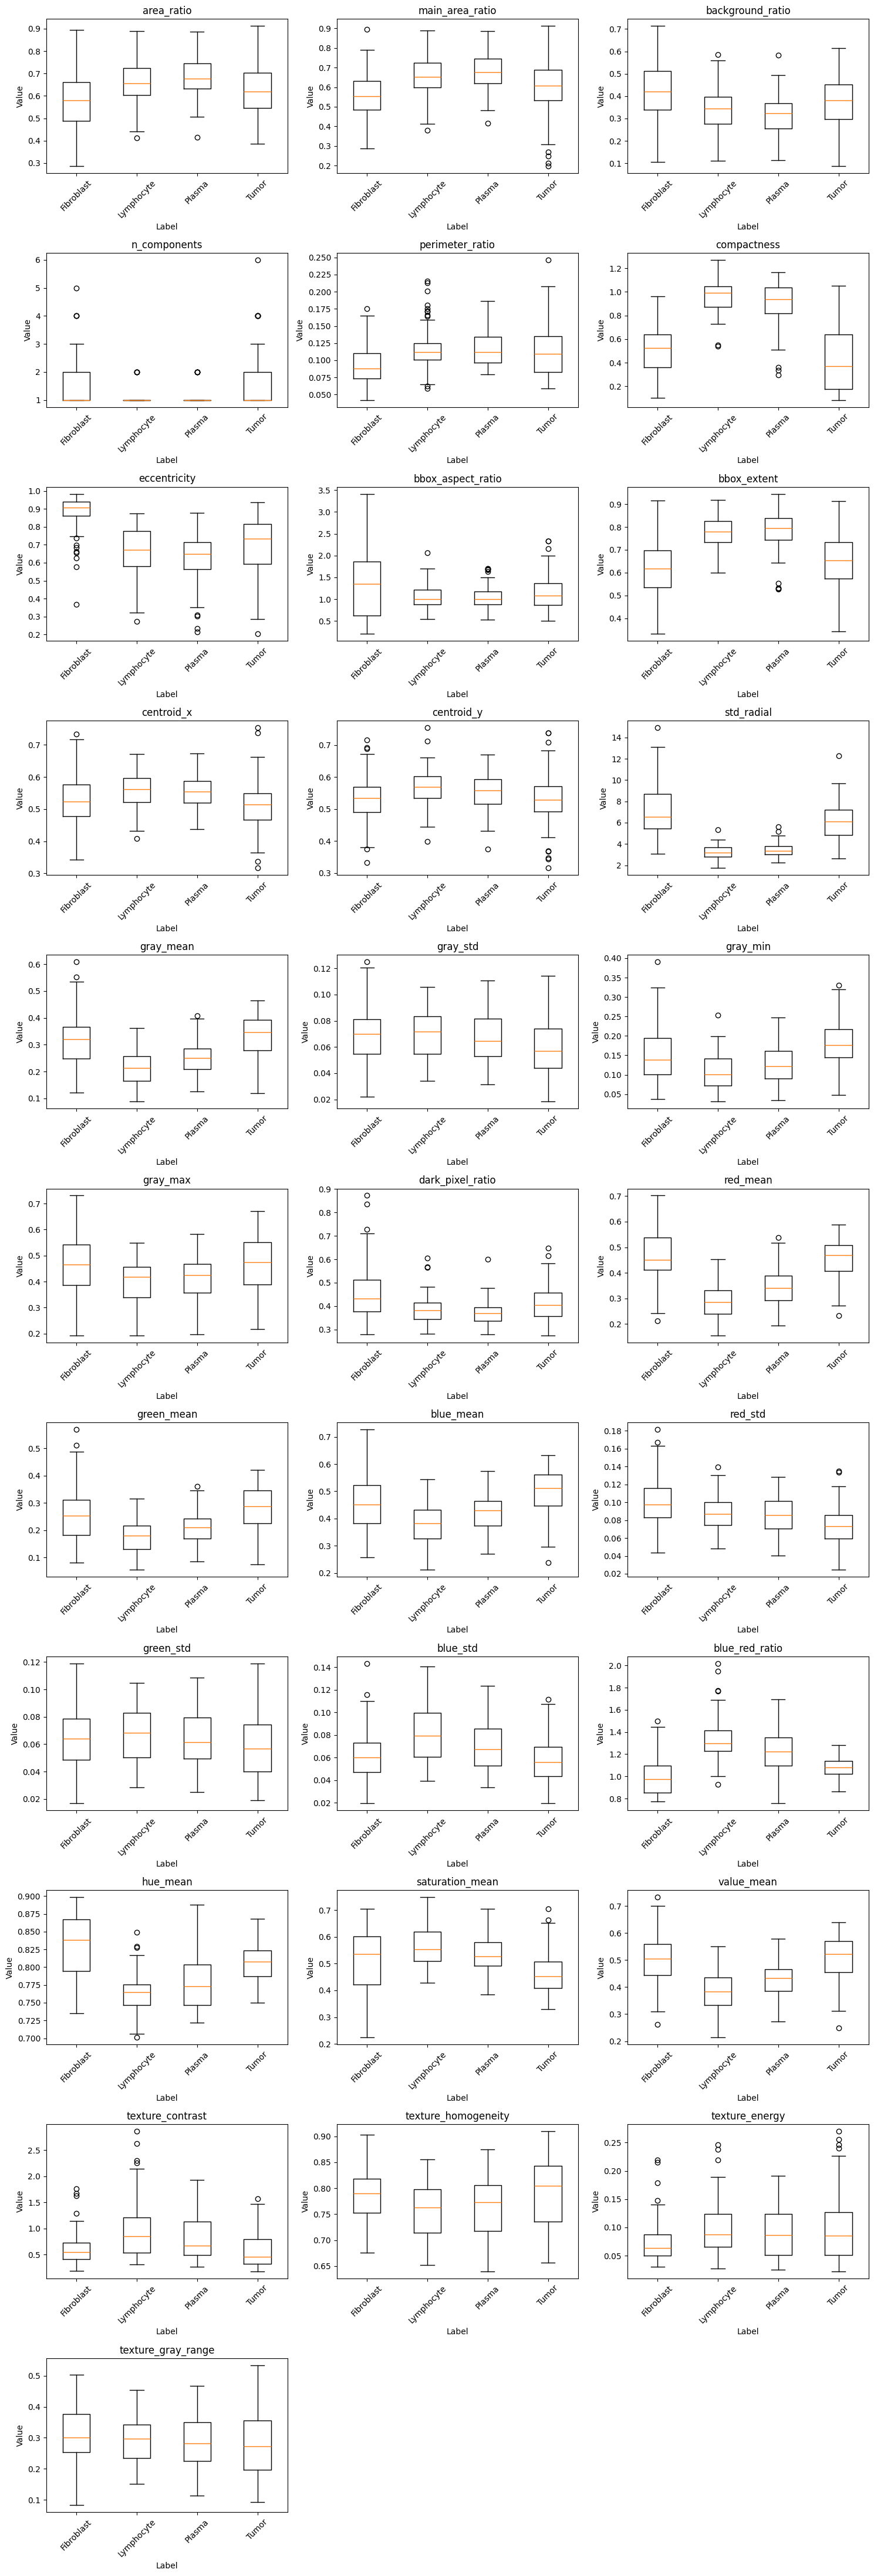

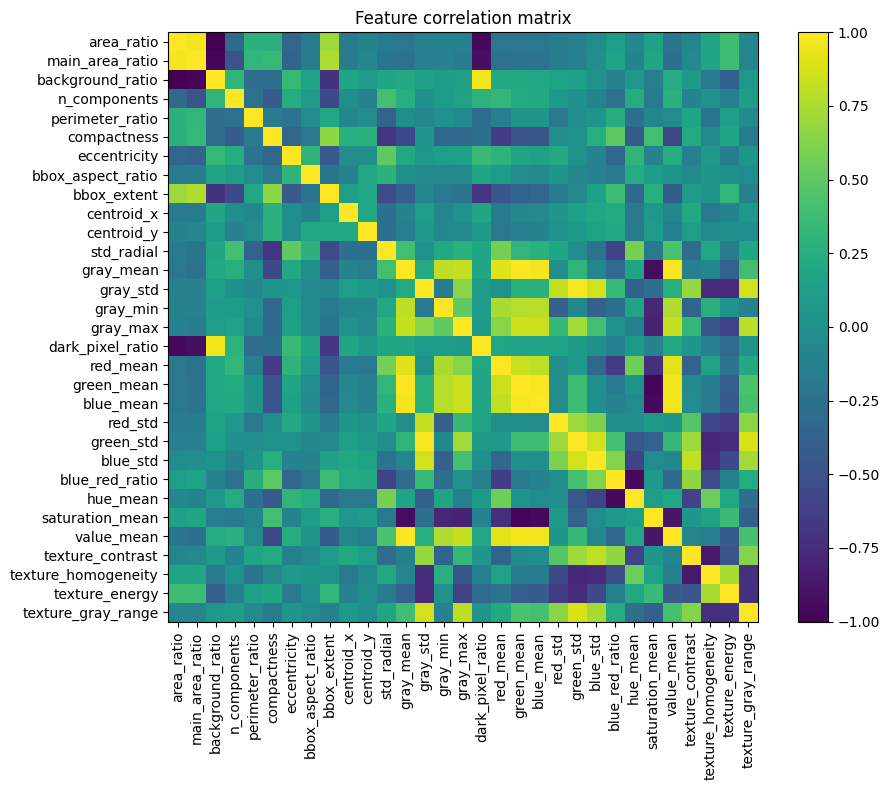

Highly correlated pairs (|r| > 0.90):
area_ratio / main_area_ratio: 0.965
area_ratio / background_ratio: -1.000
area_ratio / dark_pixel_ratio: -0.956
main_area_ratio / background_ratio: -0.965
main_area_ratio / dark_pixel_ratio: -0.921
background_ratio / dark_pixel_ratio: 0.956
gray_mean / red_mean: 0.909
gray_mean / green_mean: 0.990
gray_mean / blue_mean: 0.971
gray_mean / saturation_mean: -0.933
gray_mean / value_mean: 0.979
gray_std / green_std: 0.983
red_mean / value_mean: 0.918
green_mean / blue_mean: 0.983
green_mean / saturation_mean: -0.962
green_mean / value_mean: 0.959
blue_mean / saturation_mean: -0.956
blue_mean / value_mean: 0.957
blue_red_ratio / hue_mean: -0.954


In [14]:
feature_cols = [
    col for col in features_df.columns
    if col not in ["Image", "Label"]
]

summary_rows = []
for feat_name in feature_cols:
    row = {"feature": feat_name}
    for lab in label_names:
        values = features_df.loc[features_df["Label"] == lab, feat_name]
        row[f"{lab}_mean"] = values.mean()
        row[f"{lab}_std"] = values.std()
    summary_rows.append(row)

feature_summary_df = pd.DataFrame(summary_rows)
display(feature_summary_df)

n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.asarray(axes).ravel()

for i, feat_name in enumerate(feature_cols):
    data = [
        features_df.loc[features_df["Label"] == lab, feat_name]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .values
        for lab in label_names
    ]
    axes[i].boxplot(data, labels=[str(lab) for lab in label_names])
    axes[i].set_title(feat_name)
    axes[i].set_xlabel("Label")
    axes[i].set_ylabel("Value")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "features_boxplots_grid.png"))
plt.show()

corr = features_df[feature_cols].replace([np.inf, -np.inf], np.nan).corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "features_corr.png"))
plt.show()

high_corr_pairs = []
for i, feat_a in enumerate(feature_cols):
    for feat_b in feature_cols[i + 1:]:
        value = corr.loc[feat_a, feat_b]
        if pd.notna(value) and abs(value) > 0.90:
            high_corr_pairs.append((feat_a, feat_b, value))

print("Highly correlated pairs (|r| > 0.90):")
for feat_a, feat_b, value in high_corr_pairs:
    print(f"{feat_a} / {feat_b}: {value:.3f}")

,feature,anova_f_score
5,compactness,172.045994
11,std_radial,153.099754
17,red_mean,129.270614
23,blue_red_ratio,86.405623
8,bbox_extent,74.592391
24,hue_mean,73.542625
6,eccentricity,69.349981
26,value_mean,62.277116
12,gray_mean,57.592244
18,green_mean,39.751525


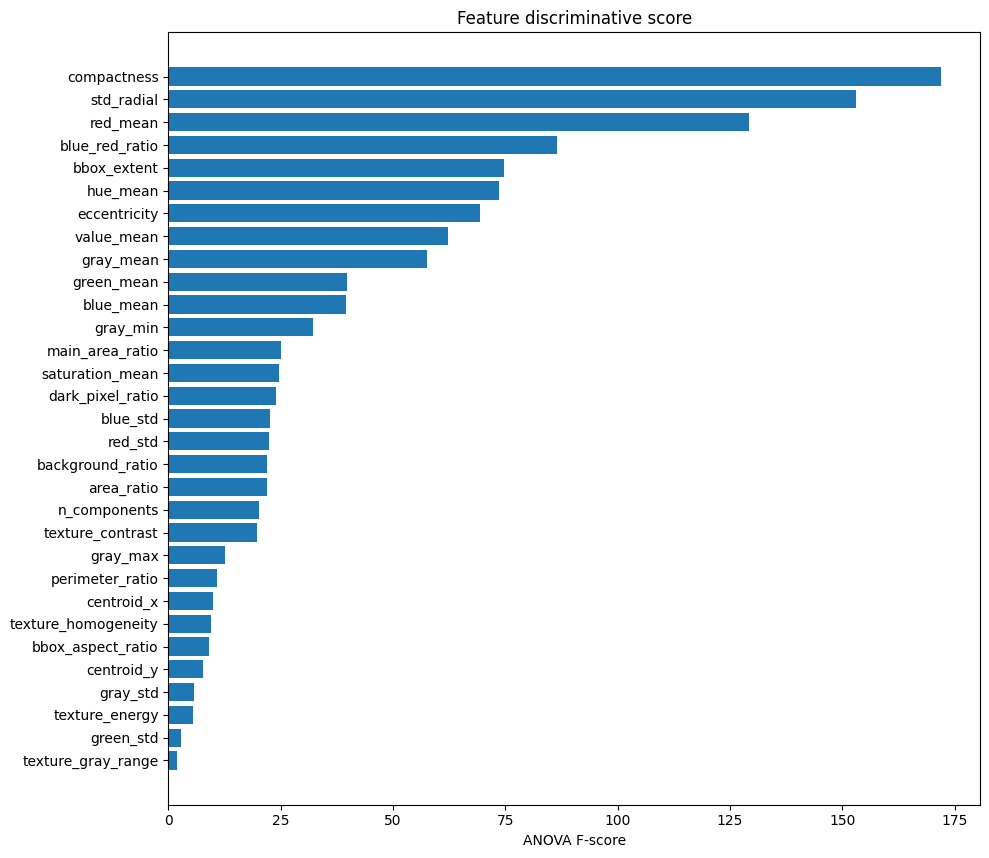

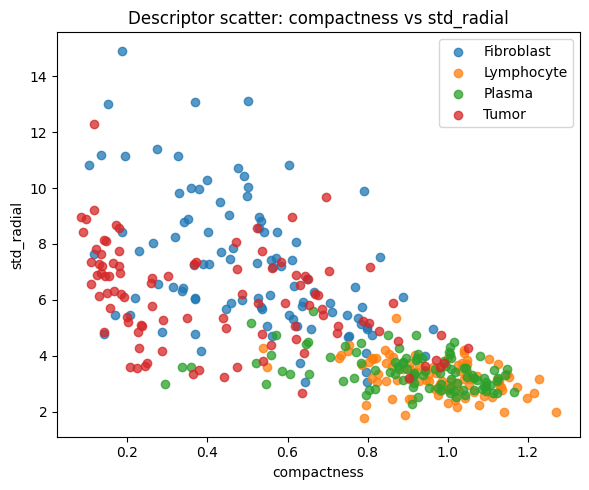

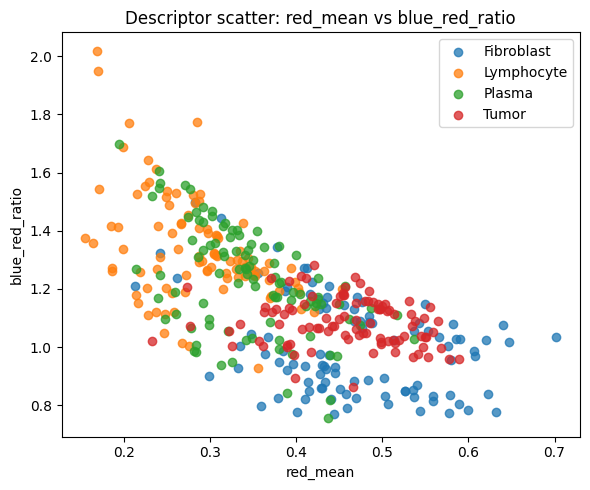

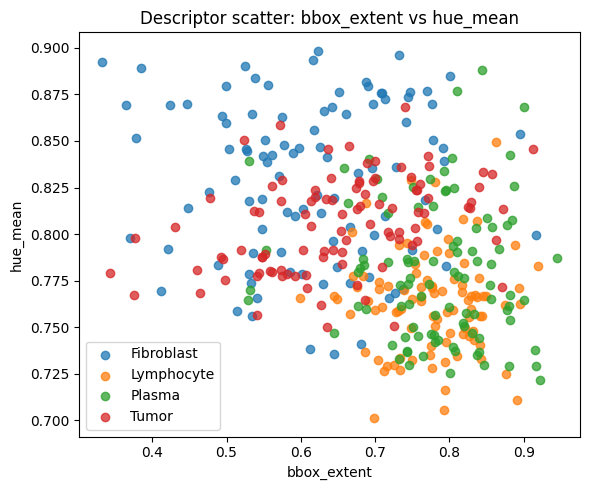

In [15]:
X_for_scores = features_df[feature_cols].replace([np.inf, -np.inf], np.nan)
X_for_scores = X_for_scores.fillna(X_for_scores.median())
y_for_scores = features_df["Label"].values

selector_preview = SelectKBest(score_func=f_classif, k="all")
selector_preview.fit(X_for_scores.values, y_for_scores)
score_df = pd.DataFrame({
    "feature": feature_cols,
    "anova_f_score": selector_preview.scores_,
}).sort_values("anova_f_score", ascending=False)

display(score_df)

plt.figure(figsize=(10, max(4, len(feature_cols) * 0.28)))
plt.barh(score_df["feature"], score_df["anova_f_score"])
plt.gca().invert_yaxis()
plt.xlabel("ANOVA F-score")
plt.title("Feature discriminative score")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_scores.png"))
plt.show()

top_features = score_df["feature"].head(6).tolist()
for i in range(0, len(top_features), 2):
    if i + 1 >= len(top_features):
        break
    feat_x = top_features[i]
    feat_y = top_features[i + 1]
    plt.figure(figsize=(6, 5))
    for lab in label_names:
        subset = features_df[features_df["Label"] == lab]
        plt.scatter(subset[feat_x], subset[feat_y], label=str(lab), alpha=0.75)
    plt.xlabel(feat_x)
    plt.ylabel(feat_y)
    plt.title(f"Descriptor scatter: {feat_x} vs {feat_y}")
    plt.legend()
    plt.tight_layout()
    out_name = f"scatter_{feat_x}_vs_{feat_y}.png".replace("/", "_")
    plt.savefig(os.path.join(FIG_DIR, out_name))
    plt.show()

## Part III — Machine learning training

In [16]:
ml_df = pd.read_csv(FEATURES_TRAIN_CSV).dropna(subset=["Label"])

selected_feature_cols = [
    "area_ratio",
    "main_area_ratio",
    "perimeter_ratio",
    "compactness",
    "eccentricity",
    "bbox_aspect_ratio",
    "bbox_extent",
    "gray_mean",
    "gray_std",
    "dark_pixel_ratio",
    "red_mean",
    "green_mean",
    "blue_mean",
    "red_std",
    "blue_std",
    "blue_red_ratio",
    "texture_contrast",
]

missing_features = [
    col for col in selected_feature_cols
    if col not in ml_df.columns
]
if missing_features:
    raise ValueError(f"Missing selected features: {missing_features}")

feature_cols = selected_feature_cols
X = ml_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = ml_df["Label"].values

n_features = len(feature_cols)
candidate_k_values = [8, 11, 14, n_features]
k_values = sorted(set(k for k in candidate_k_values if k <= n_features))

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
]

scoring_metric = "f1_weighted"
model_results = []
trained_searches = {}


def evaluate_predictions(model_name, y_true, y_pred, best_score, best_params):
    return {
        "model": model_name,
        "best_cv_f1_weighted": float(best_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "best_params": best_params,
    }


def run_grid_model(model_name, classifier, param_grid):
    pipeline = Pipeline(base_steps + [("clf", classifier)])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring_metric,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X, y)

    preds = cross_val_predict(
        search.best_estimator_,
        X,
        y,
        cv=cv,
        n_jobs=-1,
    )

    result = evaluate_predictions(
        model_name=model_name,
        y_true=y,
        y_pred=preds,
        best_score=search.best_score_,
        best_params=search.best_params_,
    )

    cm = confusion_matrix(y, preds, labels=label_names)
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_names,
    )
    display_obj.plot(xticks_rotation=30)
    plt.title(f"Cross-validated confusion matrix: {model_name}")
    plt.tight_layout()
    fig_name = f"confusion_matrix_{model_name}.png"
    plt.savefig(os.path.join(FIG_DIR, fig_name))
    plt.show()

    return result, search


print("Selected features used for machine learning:")
for feature in feature_cols:
    print("-", feature)

print("\nNumber of selected features:", n_features)
print("Feature-selection k values tested:", k_values)

Selected features used for machine learning:
- area_ratio
- main_area_ratio
- perimeter_ratio
- compactness
- eccentricity
- bbox_aspect_ratio
- bbox_extent
- gray_mean
- gray_std
- dark_pixel_ratio
- red_mean
- green_mean
- blue_mean
- red_std
- blue_std
- blue_red_ratio
- texture_contrast

Number of selected features: 17
Feature-selection k values tested: [8, 11, 14, 17]



Training: SVM_RBF


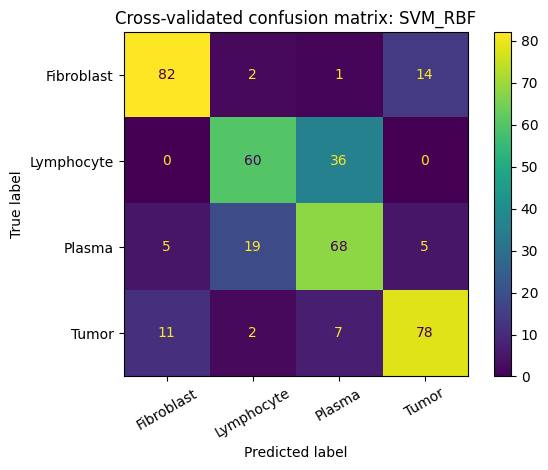

,model,best_cv_f1_weighted,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,best_params
0,SVM_RBF,0.737292,0.738462,0.737558,0.743414,0.738462,0.739214,"{'clf__C': 10.0, 'clf__gamma': 0.01, 'select__..."



Training: RandomForest


In [ ]:
models_and_grids = {
    "SVM_RBF": (
        SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
        {
            "select__k": k_values,
            "clf__C": [0.1, 1.0, 10.0, 100.0],
            "clf__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            "select__k": k_values,
            "clf__n_estimators": [100, 300, 500],
            "clf__max_depth": [None, 3, 5, 8],
            "clf__min_samples_leaf": [1, 2, 4],
        },
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "select__k": k_values,
            "clf__n_neighbors": [3, 5, 7, 9, 11],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    ),
    "LogisticRegression_LBFGS": (
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
            solver="lbfgs",
        ),
        {
            "select__k": k_values,
            "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
}

for model_name, (classifier, param_grid) in models_and_grids.items():
    print(f"\nTraining: {model_name}")
    result, search = run_grid_model(model_name, classifier, param_grid)
    model_results.append(result)
    trained_searches[model_name] = search
    display(pd.DataFrame([result]))

In [ ]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values("f1_weighted", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_search = trained_searches[best_model_name]
best_model = best_search.best_estimator_

joblib.dump(
    {
        "model": best_model,
        "feature_cols": feature_cols,
        "label_names": label_names,
        "best_model_name": best_model_name,
        "results": results_df,
    },
    MODEL_PATH,
)

print(f"Best model: {best_model_name}")
print(f"Saved model to: {MODEL_PATH}")

## Part IV — Prediction on the future test set

In [ ]:
def make_test_dataframe(test_img_dir):
    image_files = [
        file_name for file_name in os.listdir(test_img_dir)
        if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
    ]
    image_files = sorted(image_files)
    image_ids = [os.path.splitext(file_name)[0] for file_name in image_files]
    return pd.DataFrame({"Image": image_ids})


def predict_test_set(test_img_dir, output_csv):
    if not os.path.exists(test_img_dir):
        print("Test directory not found. No prediction file was created.")
        return None

    saved = joblib.load(MODEL_PATH)
    trained_model = saved["model"]
    saved_feature_cols = saved["feature_cols"]

    test_df = make_test_dataframe(test_img_dir)
    test_features_df = build_feature_table(
        test_df,
        test_img_dir,
        include_labels=False,
    )

    for col in saved_feature_cols:
        if col not in test_features_df.columns:
            test_features_df[col] = 0.0

    X_test = test_features_df[saved_feature_cols].values
    predictions = trained_model.predict(X_test)

    output_df = pd.DataFrame({
        "Image": test_features_df["Image"].values,
        "Label": predictions,
    })
    output_df.to_csv(output_csv, index=False)
    print(f"Saved predictions to: {output_csv}")
    return output_df


TEST_OUTPUT_CSV = os.path.join(DATA_DIR, "test.csv")

if os.path.exists(TEST_IMG_DIR):
    test_predictions = predict_test_set(TEST_IMG_DIR, TEST_OUTPUT_CSV)
else:
    print("Test image folder is not available yet.")